## K Means Clustering Algorithm

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [5]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [6]:
x

array([[-3.62270749,  4.02113162],
       [ 2.07510426, -6.68108247],
       [ 2.40241487,  4.63927903],
       ...,
       [ 3.35732944, -8.58577508],
       [-4.7698324 ,  4.48319494],
       [ 1.46804374,  2.28068404]], shape=(1000, 2))

In [7]:
y

array([1, 2, 0, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 0, 1, 1, 0, 2,
       1, 0, 0, 1, 2, 0, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 1, 2, 2, 1, 2, 2,
       2, 1, 1, 0, 1, 2, 2, 2, 0, 1, 0, 1, 1, 1, 0, 0, 1, 2, 1, 2, 2, 0,
       2, 0, 1, 1, 1, 1, 2, 2, 2, 2, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 2, 2, 0, 0, 1, 1, 2, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       2, 1, 1, 2, 0, 2, 0, 0, 0, 2, 0, 2, 2, 0, 1, 2, 0, 1, 1, 1, 1, 0,
       2, 2, 1, 0, 0, 1, 0, 1, 2, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1, 0, 0, 2,
       1, 1, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 2, 0, 0, 0,
       1, 2, 2, 2, 2, 1, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 0, 0, 2, 2, 2, 1, 1, 1, 2, 0, 1, 0, 0, 2, 2,
       0, 0, 1, 0, 2, 2, 2, 0, 1, 2, 1, 1, 0, 2, 1, 1, 2, 2, 2, 1, 0, 1,
       2, 1, 1, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 0, 1, 2, 2, 2, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 2, 1, 1, 1, 2, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1,
       2, 0, 1, 0, 2, 0, 0, 2, 1, 2, 1, 1, 1, 0, 0,

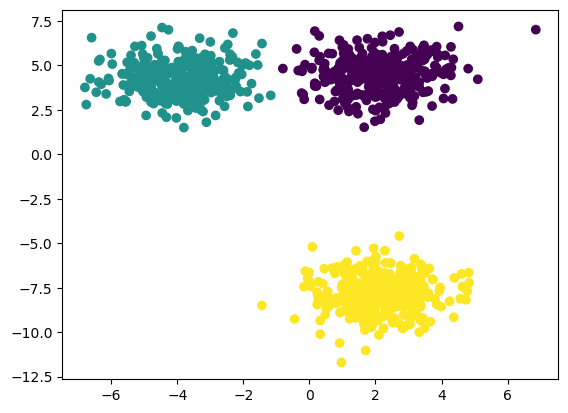

In [8]:
plt.scatter(x[:,0],x[:,1],c=y)

In [9]:
## Standardization feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.33,random_state=42)

In [14]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
from sklearn.cluster import KMeans

In [19]:
## Elbow Method to select K value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [20]:
wcss

[1340.000000000001,
 552.3176935847046,
 103.02898771141393,
 84.44990112221183,
 65.42523241690687,
 63.23819975144025,
 55.34852536078523,
 39.97848126685778,
 34.19444118229728,
 31.84399760405048]

Text(0, 0.5, 'WCSS')

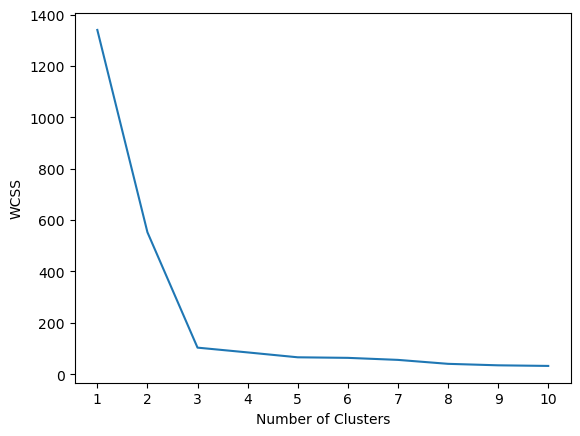

In [22]:
## plot elbow curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

In [23]:
    kmeans=KMeans(n_clusters=k,init="k-means++")


In [24]:
kmeans.fit_predict(x_train_scaled)

array([2, 8, 4, 2, 4, 1, 3, 5, 3, 6, 5, 2, 5, 7, 0, 5, 1, 3, 5, 6, 4, 4,
       9, 3, 6, 8, 2, 1, 2, 1, 9, 4, 6, 0, 2, 4, 3, 7, 7, 3, 2, 2, 5, 2,
       7, 9, 5, 0, 6, 2, 0, 1, 7, 9, 8, 4, 3, 7, 2, 6, 7, 9, 3, 2, 2, 1,
       4, 8, 3, 5, 2, 4, 4, 0, 7, 9, 7, 1, 5, 6, 7, 2, 3, 6, 2, 5, 2, 5,
       0, 1, 9, 6, 5, 4, 7, 7, 1, 7, 3, 4, 3, 6, 2, 6, 1, 0, 5, 2, 7, 4,
       8, 4, 5, 2, 9, 8, 1, 3, 6, 5, 6, 2, 2, 1, 9, 4, 7, 7, 1, 0, 7, 0,
       4, 4, 6, 8, 2, 7, 9, 6, 5, 8, 6, 6, 7, 2, 6, 6, 1, 9, 2, 4, 5, 9,
       2, 7, 7, 2, 2, 5, 2, 7, 2, 3, 3, 7, 5, 7, 5, 7, 6, 7, 8, 8, 4, 4,
       9, 1, 0, 7, 5, 3, 1, 7, 2, 5, 9, 7, 0, 3, 3, 3, 9, 7, 4, 6, 1, 0,
       6, 2, 9, 3, 0, 8, 1, 2, 7, 0, 4, 2, 0, 7, 7, 7, 6, 7, 6, 4, 0, 6,
       6, 7, 0, 3, 4, 3, 6, 6, 1, 4, 5, 6, 6, 3, 2, 4, 6, 2, 0, 5, 7, 3,
       6, 0, 2, 6, 2, 3, 5, 9, 4, 4, 0, 5, 7, 6, 3, 8, 4, 2, 9, 0, 2, 9,
       3, 3, 6, 2, 7, 2, 2, 9, 2, 6, 5, 2, 7, 5, 5, 6, 5, 7, 4, 8, 2, 5,
       3, 4, 8, 9, 7, 2, 1, 2, 4, 3, 4, 2, 8, 9, 5,

In [25]:
y_pred=kmeans.predict(x_test_scaled)

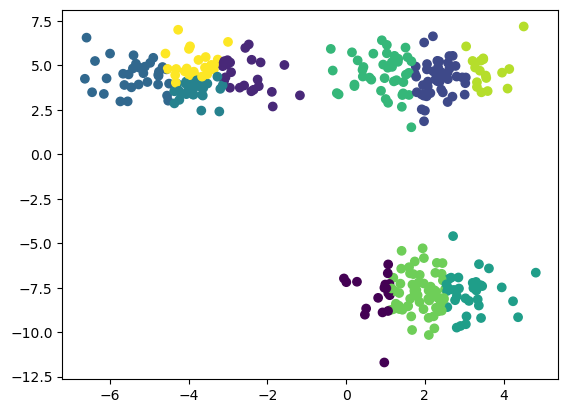

In [29]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [ ]:
## Validating the K value
## Kneelocator 
## Silhoute Scoring

In [30]:
## Kneelocator
!pip install kneed

In [32]:
from kneed import KneeLocator

In [33]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [34]:
kl.elbow

np.int64(3)

In [35]:
## Silhoute Scoring
from sklearn.metrics import silhouette_score

In [38]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [39]:
silhouette_coefficients

[0.6005728780163154,
 0.759605006355285,
 0.6482473621187319,
 0.5485352273129509,
 0.44396372394247624,
 0.43237581493910404,
 0.41080274432470476,
 0.37851807713642294,
 0.3854074866675823]

AttributeError: module 'matplotlib.pyplot' has no attribute 'ticks'

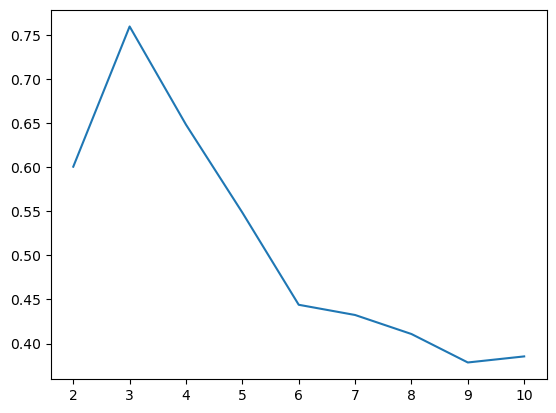

In [40]:
plt.plot(range(2,11),silhouette_coefficients)
plt.ticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutee Coefficient")
plt.show()